# Breast Cancer Analysis - Survival data

Make sure that all the following libraries are installed:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats

import sys
import os

# Get absolute path to "scr"
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

#Importing functions from utils
from utils.view3D import plot_3d_plotly
from utils.Statistics import cohens_d,centroid_dist,norm_centroid_dist

# Reading data base

### Database name:
* BC_database_final_version.db
### Database structure:
* **df1:** Breast_Cancer_Original
* **df2:** Breast_Cancer_Wisconsin
* **df3:** Breast_Cancer_Metabric
---


# Data Set 3
* Breast Cancer (Metabric)

**Link:** https://www.kaggle.com/datasets/gunesevitan/breast-cancer-metabric

In [2]:
import sqlite3
import pandas as pd
import os

# Build correct path
db_path = os.path.join("..", "data", "BC_database_final_version.db")

conn = sqlite3.connect(db_path)

df3 = pd.read_sql_query("SELECT * FROM Breast_Cancer_Metabric", conn)
conn.close()


In [6]:
df3

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
1,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
2,MB-0010,78.77,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Positive,Yes,2.89,Recurred,Female,ER+/HER2- High Prolif,31.0,4.0,Died of Disease
3,MB-0028,86.41,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Negative,Yes,36.09,Not Recurred,Female,ER+/HER2- High Prolif,16.0,2.0,Died of Other Causes
4,MB-0035,84.22,Mastectomy,Breast Cancer,Breast Invasive Lobular Carcinoma,High,No,Her2,1.0,Negative,...,Deceased,Negative,No,35.79,Recurred,Female,ER+/HER2- High Prolif,28.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,MB-6232,71.22,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,No,LumA,5.0,Positve,...,Deceased,Positive,No,83.88,Not Recurred,Female,ER+/HER2- Low Prolif,30.0,2.0,Died of Other Causes
1088,MB-6233,70.65,Breast Conserving,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,No,LumB,5.0,Positve,...,Living,Positive,Yes,198.52,Not Recurred,Female,ER+/HER2- Low Prolif,20.0,1.0,Living
1089,MB-6237,75.62,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,Basal,5.0,Negative,...,Deceased,Negative,No,103.82,Not Recurred,Female,ER-/HER2-,20.0,1.0,Died of Other Causes
1090,MB-6239,52.84,Breast Conserving,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,Normal,5.0,Positve,...,Living,Positive,Yes,197.70,Not Recurred,Female,ER+/HER2- High Prolif,20.0,2.0,Living


In [22]:
df3

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
1,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
2,MB-0010,78.77,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Positive,Yes,2.89,Recurred,Female,ER+/HER2- High Prolif,31.0,4.0,Died of Disease
3,MB-0028,86.41,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Deceased,Negative,Yes,36.09,Not Recurred,Female,ER+/HER2- High Prolif,16.0,2.0,Died of Other Causes
4,MB-0035,84.22,Mastectomy,Breast Cancer,Breast Invasive Lobular Carcinoma,High,No,Her2,1.0,Negative,...,Deceased,Negative,No,35.79,Recurred,Female,ER+/HER2- High Prolif,28.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,MB-6232,71.22,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,No,LumA,5.0,Positve,...,Deceased,Positive,No,83.88,Not Recurred,Female,ER+/HER2- Low Prolif,30.0,2.0,Died of Other Causes
1088,MB-6233,70.65,Breast Conserving,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,No,LumB,5.0,Positve,...,Living,Positive,Yes,198.52,Not Recurred,Female,ER+/HER2- Low Prolif,20.0,1.0,Living
1089,MB-6237,75.62,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,Basal,5.0,Negative,...,Deceased,Negative,No,103.82,Not Recurred,Female,ER-/HER2-,20.0,1.0,Died of Other Causes
1090,MB-6239,52.84,Breast Conserving,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,Normal,5.0,Positve,...,Living,Positive,Yes,197.70,Not Recurred,Female,ER+/HER2- High Prolif,20.0,2.0,Living


In [24]:
df3.shape

(1092, 34)

In [4]:
df3.columns

Index(['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery',
       'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status'],
      dtype='object')

In [72]:
info="Patient's Vital Status"

In [93]:
new_columns=['Age at Diagnosis',
 #'Cohort',
 'Neoplasm Histologic Grade',
 'Lymph nodes examined positive',
 'Mutation Count',
# 'Nottingham prognostic index',
# 'Overall Survival (Months)',
 #'Relapse Free Status (Months)',
 'Tumor Size',
# 'Tumor Stage'
            ]

<Figure size 1000x1000 with 0 Axes>

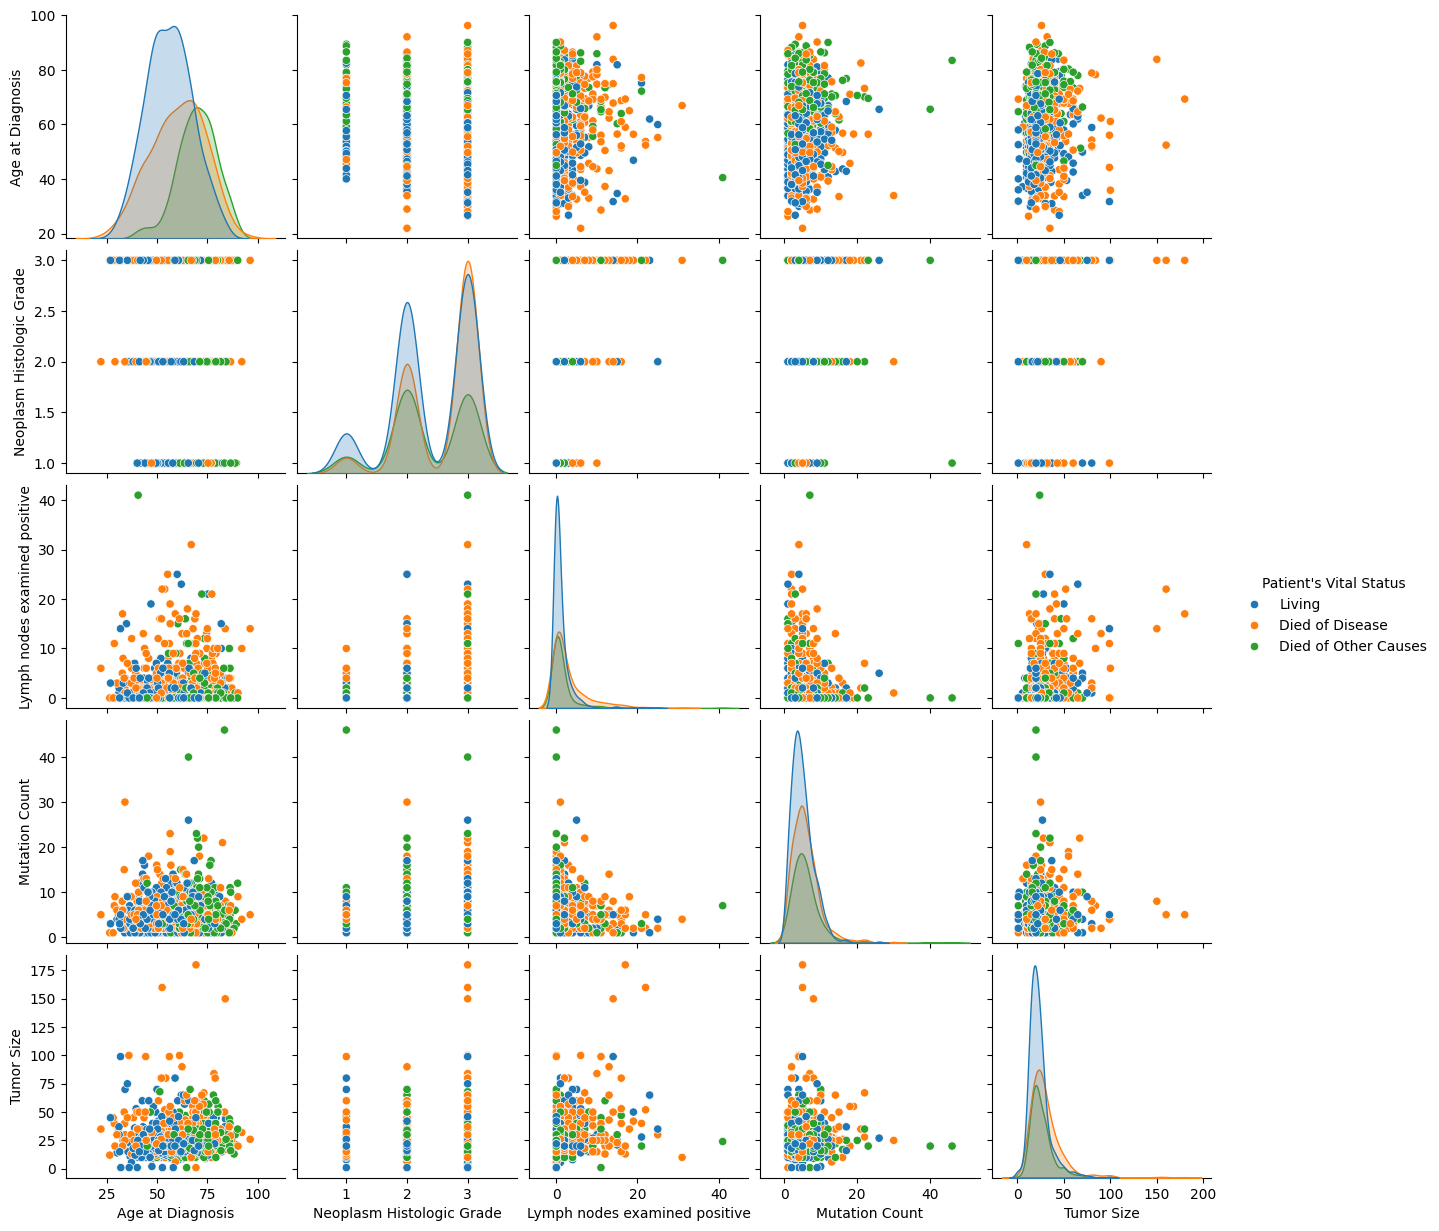

In [98]:
plt.figure(figsize=(10,10))
sns.pairplot(df3[new_columns+[info]],hue=info)
plt.savefig("BC_pairplot_survival_status.png",dpi=150,bbox_inches="tight")

# Conclusion:
* No statistical relevance for distinguishing patient status

# Plotting information in function of tumor stage:

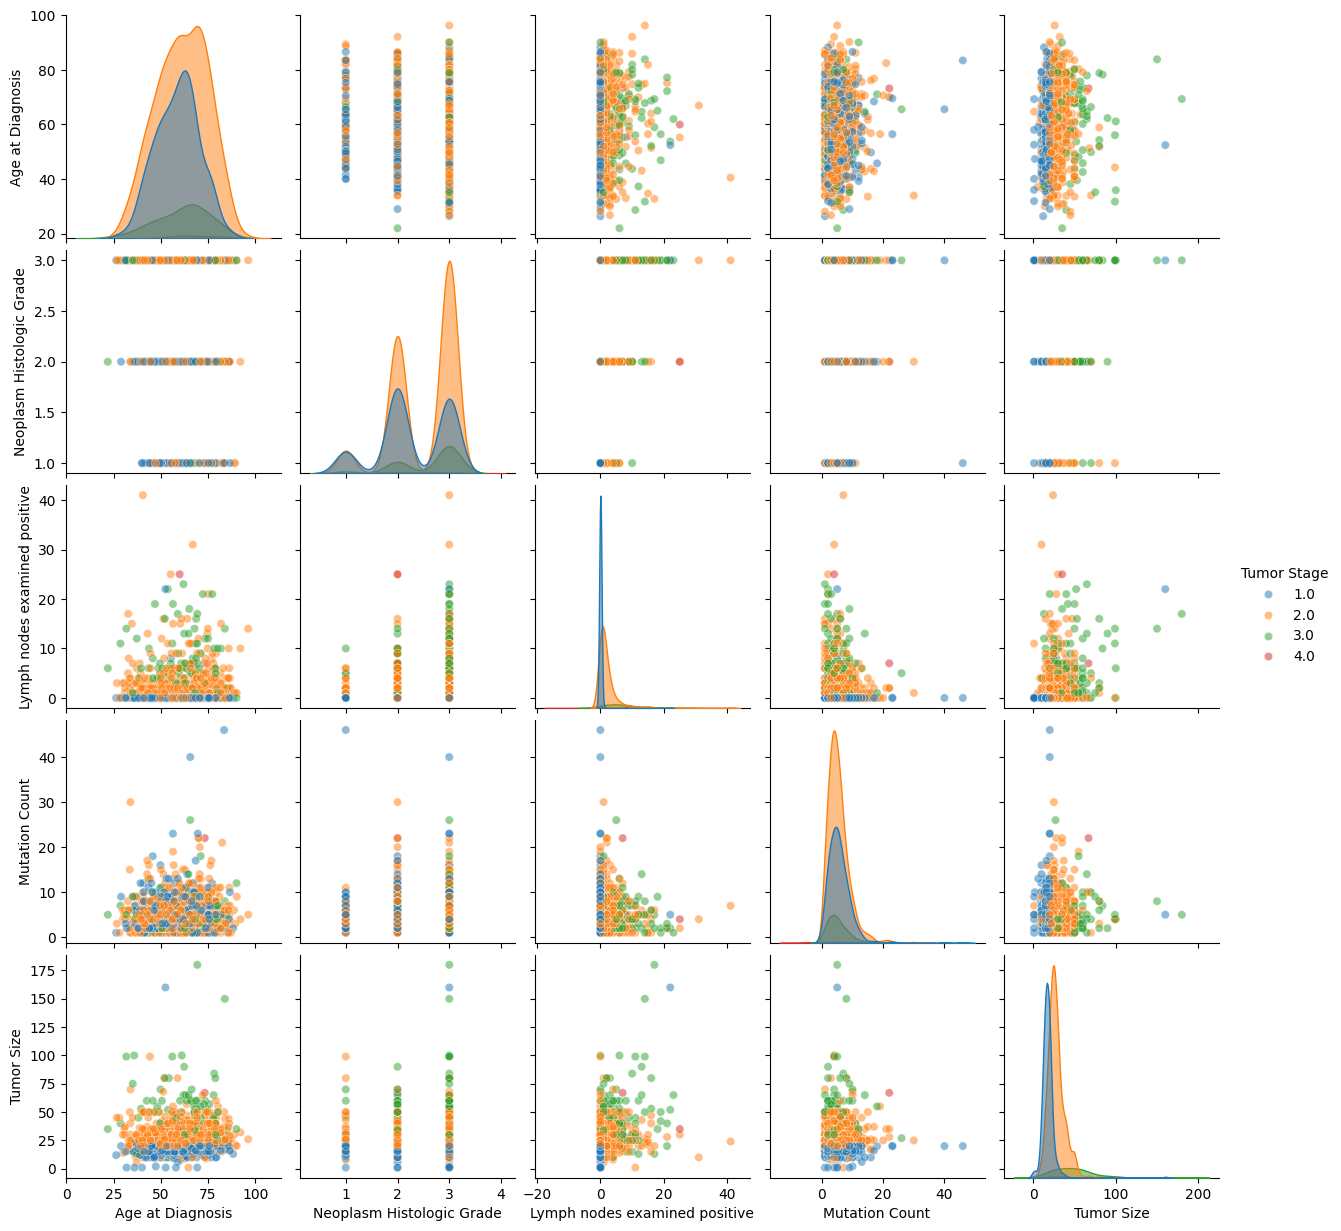

<Figure size 1000x1000 with 0 Axes>

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

info="Tumor Stage"
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # 4 solid colors

sns.pairplot(
    df3[new_columns + [info]],
    hue=info,
    palette=palette,
     plot_kws={'alpha': 0.5},
    diag_kws={'alpha': 0.5},
)

plt.figure(figsize=(10,10))


# Restricting to tumor features ("Age at Diagnosis","Tumor Size", "Mutation Count","Lymph nodes examined positive")

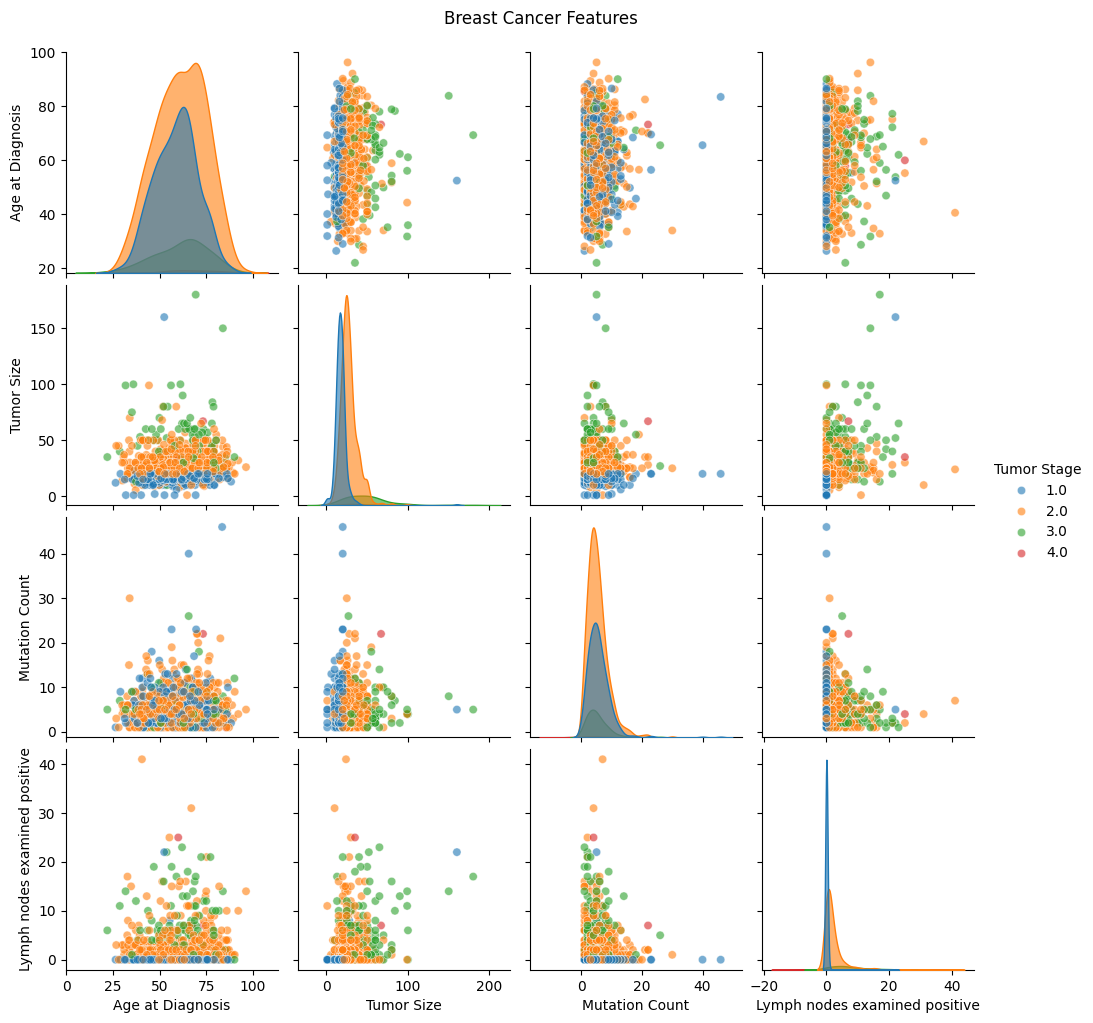

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
info="Tumor Stage"
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # 4 solid colors

g = sns.pairplot(
    df3[["Age at Diagnosis","Tumor Size", "Mutation Count","Lymph nodes examined positive"] + [info]],
    hue=info,
    palette=palette,
    plot_kws={'alpha': 0.6},
    diag_kws={'alpha': 0.6},
    height=2.5  # controls size of each subplot
)

g.fig.suptitle("Breast Cancer Features", y=1.02)
plt.savefig("BC_pairplot_tumor_stage.png",dpi=150,bbox_inches="tight")

# Conclusion:
* There is some statistical relevance to distinguish cancer stage

In [75]:
X0=df3[["Age at Diagnosis","Tumor Size", "Mutation Count"]].to_numpy()
y0=df3["Tumor Stage"].to_numpy()

In [97]:
fig=plot_3d_plotly(X0,y0,title="3D scatter plot (Age at Diagnosis,Tumor Size, Mutation Count)")
fig.write_html("3D_plot_BC_tumor_stage.html")

# EXTRA: Data Dimensionality Reduction and Visualization:
Here, we test the data visualization through different data dimensionality reduction methods:

1. PCA;
2. Isomap;
3. t-SNE:
4. UMAP

**WARNING:** Make sure you have sklearn and umap libraries installed.

In [77]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from umap import UMAP

In [78]:
df_numeric = df3.select_dtypes(include=['number'])

In [79]:
X=df_numeric[list(df_numeric)[:-1]].to_numpy()
y=df3["Tumor Stage"].to_numpy()

# PCA:

In [80]:
P=PCA( n_components=3)
P0=P.fit_transform(X)

In [81]:
fig=plot_3d_plotly(P0,y,title="3D Plot with PCA")


# Isomap:

In [82]:
I=Isomap(n_neighbors=15,metric="euclidean",n_components=3)
I0=I.fit_transform(X)

In [83]:
fig=plot_3d_plotly(I0,y,title="3D Plot with Isomap")


# t-SNE:

In [84]:
T=TSNE(perplexity=15 ,n_components=3)
T0=T.fit_transform(X)

In [85]:
fig=plot_3d_plotly(T0,y,title="3D Plot with t-SNE")


# UMAP:

In [86]:
U=UMAP(n_neighbors=15,min_dist=0.1,metric="euclidean",n_components=3)
U0=U.fit_transform(X)

In [87]:
fig=plot_3d_plotly(U0,y,title="3D Plot with UMAP")
